In this notebook, we consider the results for the rational quadratic correlation function.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy as np
import torch
import os # Added os import
import scipy
import scipy.linalg
# Removed gaussian_crossings.utils import as MidpointNormalize is replaced
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from joblib import Parallel, delayed
import time


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}" 
})

In [2]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [3]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
    mean_label = r'$\mathbb{E}\left[N^\downarrow_u(T)\right]/ \,T$'
    variance_label = r'Var$\left[N^\downarrow_u(T)\right]/ \,T$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
    mean_label = r'$\mathbb{E}\left[N^\uparrow_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N^\uparrow_u(T)\right]/ \, T$'
else:
    fano_label = r'$\mathrm{F}$'
    mean_label = r'$\mathbb{E}\left[N_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N_u(T)\right]/ \, T$'

In [4]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
alpha = 3/2  # Shape parameter controlling the relative weighting of different scales
sigma = 1.0 # Standard deviation (amplitude) of the process

In [5]:
num_points_taus = 20
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_psi = 20
psi = torch.linspace(0.0, 3.0, num_points_psi)

mean_rates = torch.zeros(num_points_taus, num_points_psi)
fano_factors = torch.zeros(num_points_taus, num_points_psi)

In [6]:
def calculate_metrics_rq(i, j, tau_val, psi_val, sigma_val, alpha_val, ModelClass, mean_rate_method, fano_method):
    """Calculates metrics for the rational quadratic model."""
    u = psi_val * sigma_val
    model = ModelClass(r_func=process.r_rational_quadratic, u=u, tau=tau_val, sigma=sigma_val, alpha=alpha_val)
    mean_rate = getattr(model, mean_rate_method)()
    fano_factor = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)
    return i, j, mean_rate, fano_factor

# Create list of delayed tasks
print("Preparing tasks for phase diagram parallel execution...")
start_time_phase = time.time()
tasks_phase = [delayed(calculate_metrics_rq)(i, j, taus[i], psi[j], sigma, alpha, ModelClass, mean_rate_method, fano_method)
               for i in range(num_points_taus) for j in range(num_points_psi)]

# Execute tasks in parallel
print(f"Starting parallel computation for phase diagram with {len(tasks_phase)} tasks...")
results_phase = Parallel(n_jobs=-1, backend='loky', verbose=1)(tasks_phase)
end_time_phase = time.time()
print(f"Parallel computation for phase diagram finished in {end_time_phase - start_time_phase:.2f} seconds.")

# Process results
for result_tuple in results_phase:
    i, j, mean_rate, fano_factor = result_tuple
    mean_rates[i, j] = mean_rate
    fano_factors[i, j] = fano_factor


# find the variance
variance = fano_factors * mean_rates

Preparing tasks for phase diagram parallel execution...
Starting parallel computation for phase diagram with 400 tasks...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    6.2s


Parallel computation for phase diagram finished in 6.73 seconds.


[Parallel(n_jobs=-1)]: Done 393 out of 400 | elapsed:    6.7s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    6.7s finished


In [7]:
# for i in range(num_points_taus):
#     for j in range(num_points_psi):
#         u = psi[j] * sigma
#         tau = taus[i]
#         model = ModelClass(r_func=process.r_rational_quadratic, u=u, tau=tau, sigma=sigma, alpha=alpha)
#         mean_rates[i, j] = getattr(model, mean_rate_method)()
#         fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

Info: Max Fano factor <= 1. Using sequential colormap (below).
Saving figures to: ../../figures/rational_quadratic/phase_diagram_upcrossing


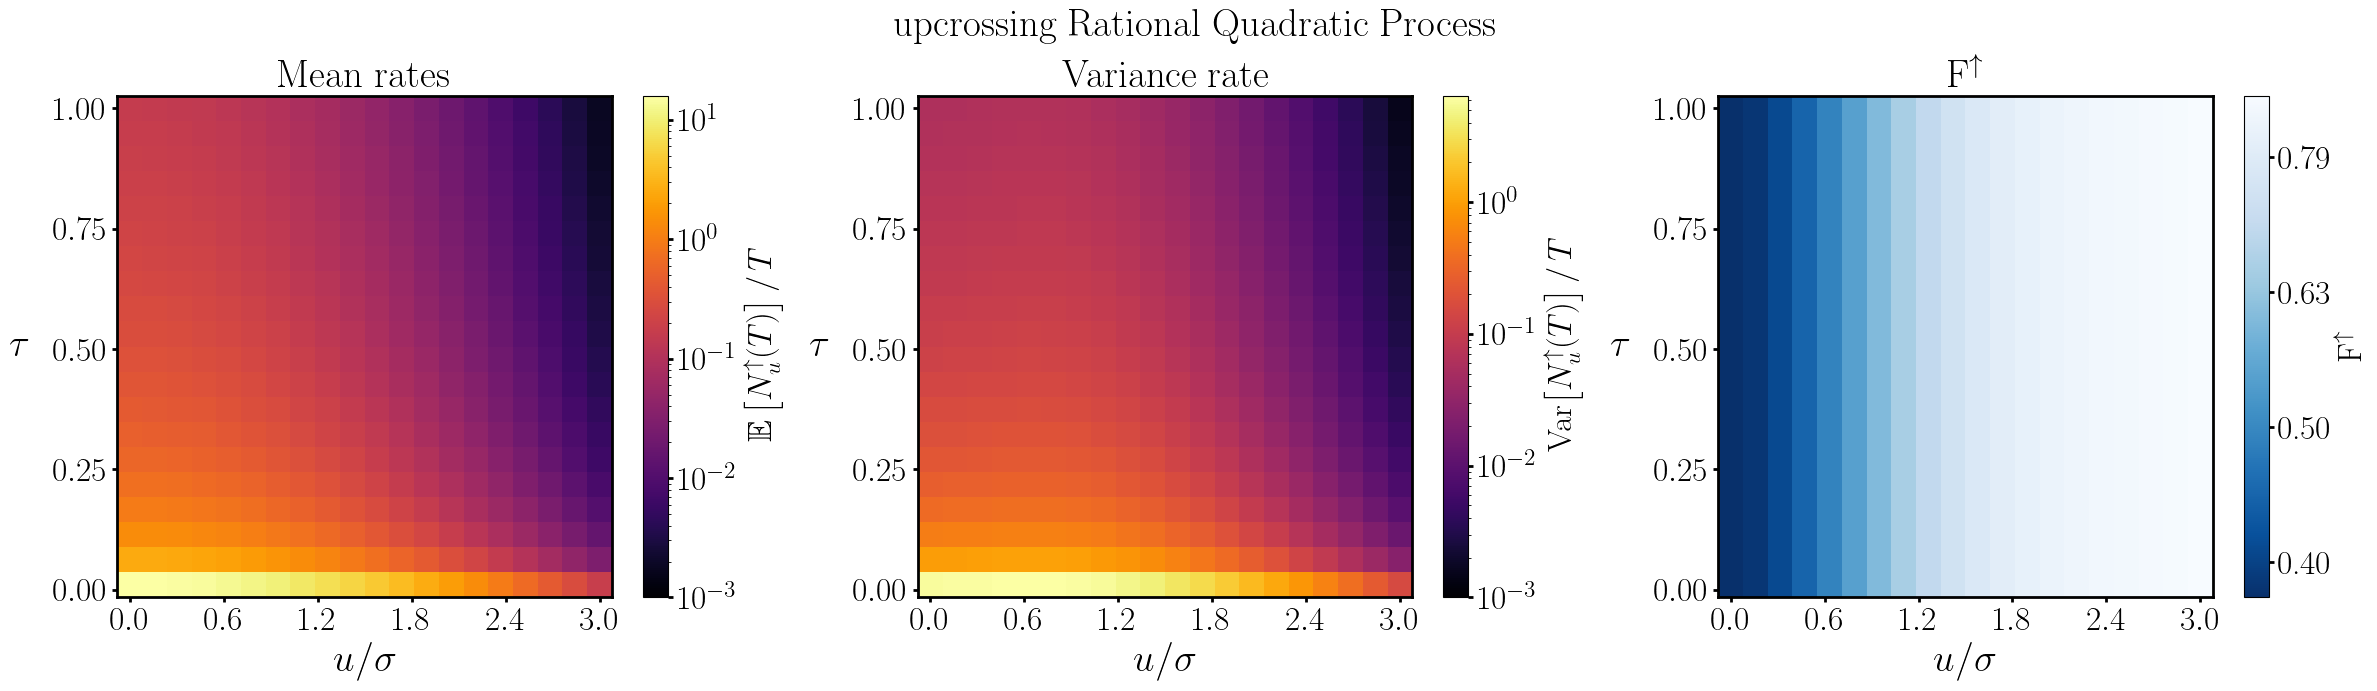

In [8]:
axis_label_fontsize = 28
tick_label_fontsize = 24
num_x_ticks = 6
num_y_ticks = 5
tick_line_width = 2.0
spine_line_width = 2.0

# Colormaps (Adopted from reference code)
cmap_mean = 'inferno'
cmap_variance = 'inferno'
cmap_diverging = 'PRGn'
cmap_below_1 = 'Blues_r'
cmap_above_1 = 'Reds'

# --- Fano Factor Colormap Logic (Adopted from reference code) ---
fano_min = fano_factors.min().item()
fano_max = fano_factors.max().item()
spans_one = (fano_min < 1.0) and (fano_max > 1.0)

fano_log = torch.log10(fano_factors)
fano_log_np = fano_log.cpu().numpy() # Ensure data is NumPy array on CPU
log_min = fano_log_np.min()
log_max = fano_log_np.max()

# Select Colormap and Normalization based on range
if spans_one:
    print("Info: Fano factor spans 1. Using diverging colormap.")
    cmap_fano = cmap_diverging
    norm_fano = mcolors.TwoSlopeNorm(vmin=log_min, vcenter=0, vmax=log_max) # Centered at log10(1)=0
else:
    if fano_max <= 1.0:
        print("Info: Max Fano factor <= 1. Using sequential colormap (below).")
        cmap_fano = cmap_below_1
    else: # fano_min >= 1.0
        print("Info: Min Fano factor >= 1. Using sequential colormap (above).")
        cmap_fano = cmap_above_1
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max) # Simple log normalization


# -----------------------
# Create the figure and subplots
# Adjusted figsize slightly based on reference code
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ---- Left subplot: Mean Rates ----
epsilon = 1e-3 # Keep epsilon threshold
# Use torch.clip as in reference code
adjusted_mean_rates = torch.clip(mean_rates, epsilon, None)
# Use mcolors.LogNorm as in reference code
log_norm = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(psi, taus, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
# Apply new styling (from reference code)
cbar0.set_label(mean_label, fontsize=tick_label_fontsize)
cbar0.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new styling (from reference code)
axes[0].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[0].set_ylabel(r'$\tau$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25)
axes[0].set_title('Mean rates', fontsize=axis_label_fontsize)

# Apply new tick locator and styling (from reference code)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new spine width (from reference code)
for spine in axes[0].spines.values():
    spine.set_linewidth(spine_line_width)


# ------------- Middle subplot: Variance -------------
epsilon = 1e-3
adjusted_variance = torch.clip(variance, epsilon, None)
log_norm_var = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_variance.max())

pc1 = axes[1].pcolormesh(psi, taus, adjusted_variance, shading='auto',
                         cmap=cmap_variance, norm=log_norm_var)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label(variance_label, fontsize=tick_label_fontsize)
cbar1.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

axes[1].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[1].set_ylabel(r'$\tau$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25)
axes[1].set_title('Variance rate', fontsize=axis_label_fontsize)

axes[1].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

for spine in axes[1].spines.values():
    spine.set_linewidth(spine_line_width)


# ---- Right subplot: Fano Factors ----
# Use fano_log calculated earlier, cmap_fano and norm_fano determined by logic above
pc2 = axes[2].pcolormesh(psi, taus, fano_log_np, shading='auto', # Use numpy array here
                         cmap=cmap_fano, norm=norm_fano)
cbar2 = fig.colorbar(pc2, ax=axes[2])
# Apply new styling (from reference code)
cbar2.set_label(fano_label, fontsize=tick_label_fontsize) # Use defined fano_label
cbar2.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

# Keep original log tick formatter (from reference code)
def log_tick_formatter(x, pos):
    return f"{10**x:.2f}"
cbar2.formatter = mticker.FuncFormatter(log_tick_formatter)
cbar2.update_ticks()

# Apply new styling (from reference code)
axes[2].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[2].set_ylabel(r'$\tau$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25)
axes[2].set_title(fano_label, fontsize=axis_label_fontsize) # Use defined fano_label

# Apply new tick locator and styling (from reference code)
axes[2].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[2].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[2].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new spine width (from reference code)
for spine in axes[2].spines.values():
    spine.set_linewidth(spine_line_width)

# Apply new font size to suptitle and update process name
fig.suptitle(f"{crossing_type} Rational Quadratic Process", fontsize=axis_label_fontsize) # Updated process name

plt.tight_layout()

# --- Save the figure (Adopted from reference code) ---
# Adapt folder location for the rational quadratic process
folder_loc = f'../../figures/rational_quadratic/'
os.makedirs(folder_loc, exist_ok=True) # Create folder if it doesn't exist
file_name = f'phase_diagram_{crossing_type}'
file_save_path = os.path.join(folder_loc, file_name)

print(f"Saving figures to: {file_save_path}")
# plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

In [9]:
model = ModelClass(r_func=process.r_rational_quadratic, u=1.0, tau=0.01, sigma=sigma, alpha=alpha)
print(getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5))

tensor(0.6201)


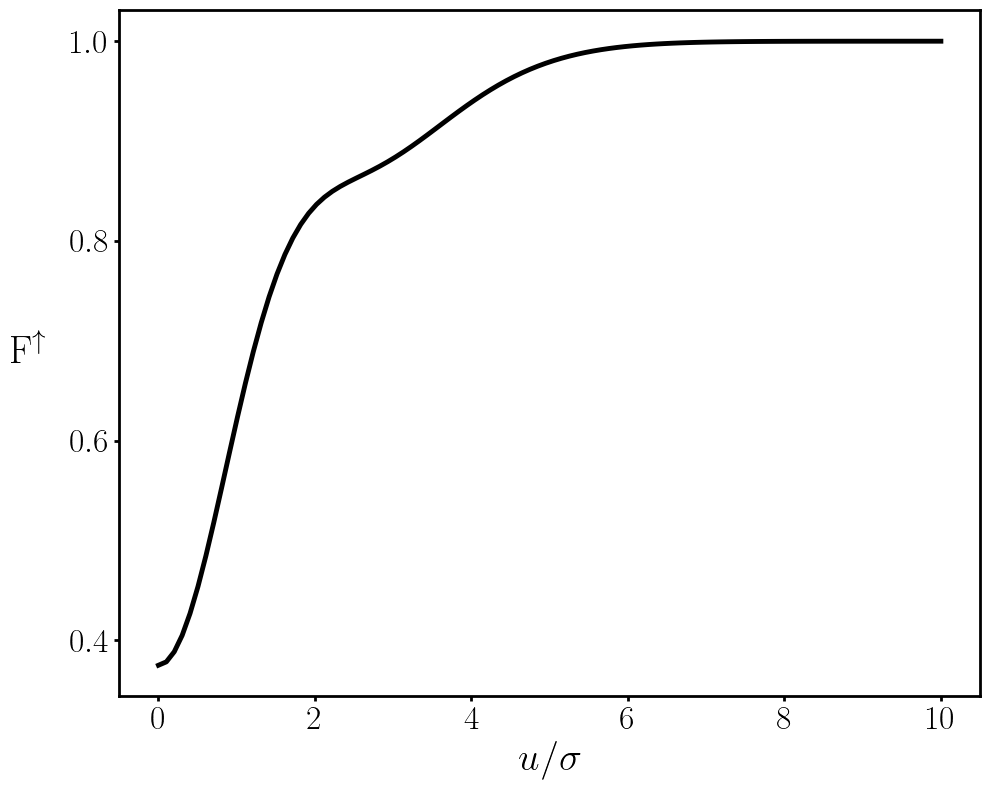

In [11]:
axis_label_fontsize = 28 # Fontsize for x and y labels & titles
tick_label_fontsize = 24 # Fontsize for tick labels & cbar labels/ticks
num_x_ticks = 6          # Desired number of ticks on the x-axis
num_y_ticks = 4          # Desired number of ticks on the y-axis
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border


# plotting the fano factor curve as a function of u for any tau
sigma = 1.0
alpha = 3/2

psi = torch.linspace(0.0, 10.0, 100)
fano_factors = torch.zeros_like(psi)


for i in range(len(psi)):
    model = ModelClass(r_func=process.r_rational_quadratic, u=psi[i] * sigma, tau=1.0, sigma=sigma, alpha=alpha)
    fano_factors[i] = getattr(model, fano_method)()

# Plot the results
plt.figure(figsize=(10, 8))
ax = plt.gca()

ax.plot(psi, fano_factors, linewidth=3.5, color='k') 

# Apply new styling (labels, ticks, spines)
ax.set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize) # Apply new font size
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Apply new font size and rotation

# Apply new tick locator, label size, and line width settings
ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks)) # REPLACE original MaxNLocator call
ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks)) # REPLACE original MaxNLocator call
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

#save the figure
plt.tight_layout() 
folder_loc = f'../../figures/rational_quadratic/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'fano_factor_{crossing_type}_psi' 
file_save_path = os.path.join(folder_loc, file_name)
# plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show() 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


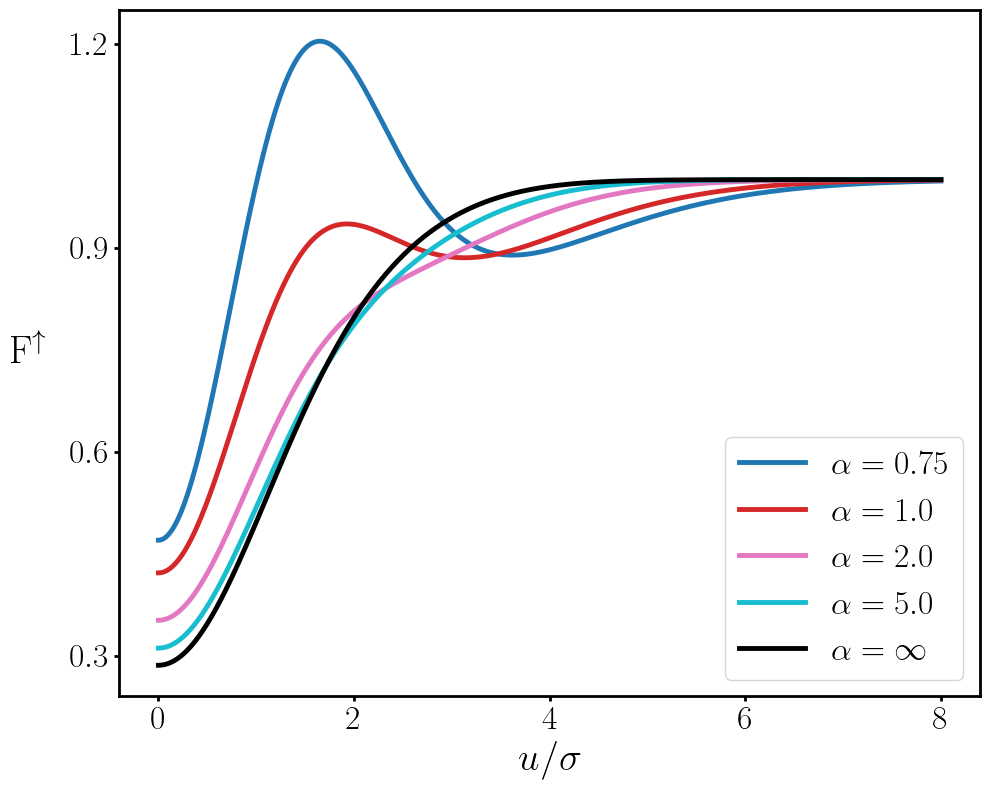

In [21]:
# fano factor vs psi for different alpha values

# Define the range for psi and the different alpha values
psi = torch.linspace(0.0, 8.0, 500)
alpha_values = [0.75, 1.0, 2.0, 5.0, np.inf]  # You can specify any number of alpha values

# Create a discrete colormap using viridis
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, len(alpha_values)-1))

axis_label_fontsize = 28 # Fontsize for x and y labels & titles
tick_label_fontsize = 24 # Fontsize for tick labels & cbar labels/ticks
num_x_ticks = 5          # Desired number of ticks on the x-axis
num_y_ticks = 4          # Desired number of ticks on the y-axis
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border
legend_fontsize = tick_label_fontsize # Match legend font size to tick labels

plt.figure(figsize=(10, 8))
ax = plt.gca()

for idx, alpha in enumerate(alpha_values):
    fano_factors = torch.zeros_like(psi)
    for i in range(len(psi)):
        if alpha == np.inf:
            model = ModelClass(
                r_func=process.r_squared_exp,
                u=psi[i] * sigma,
                tau=1.0,
                sigma=sigma
            )
        else:
            model = ModelClass(
                r_func=process.r_rational_quadratic,
                u=psi[i] * sigma,
                tau=1.0,
                sigma=sigma,
                alpha=alpha
            )
        fano_factors[i] = getattr(model, fano_method)()
    if alpha == np.inf:
        ax.plot(psi.numpy(), fano_factors.numpy(), linewidth=3.5,
                 color='k', label=rf'$\alpha = \infty$')
    else:
        ax.plot(psi.numpy(), fano_factors.numpy(), linewidth=3.5,
                 color=colors[idx], label=rf'$\alpha = {alpha}$')

ax.set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize) # Apply new font size
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Apply new font size and rotation

ax.legend(fontsize=legend_fontsize, loc='best')

# Apply new tick locator, label size, and line width settings
ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks)) # REPLACE original MaxNLocator call
ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks)) # REPLACE original MaxNLocator call
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

#save the figure
plt.tight_layout() 
folder_loc = f'../../figures/rational_quadratic/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'fano_factor_{crossing_type}_psi_alpha' 
file_save_path = os.path.join(folder_loc, file_name)
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()